## **Random Wallpaper Generator (DCGAN + Real-ESRGAN)**
CSE 25 - University of California, San Diego

**Team "The Best Boys":** Nathan Man, Christian Tchakmakjian, Sergio Pena, Samuel Suner

This project trains a DCGAN to generate wallpaper-style images from a paintings dataset, then upscales the generated outputs using Real-ESRGAN for higher resolution

**1. Environment Setup**

Install the required libraries. We use a GitHub version of BasicSR, then install Real-ESRGAN and OpenCV for upscaling and image saving.

In [ ]:
# Documents
# https://docs.google.com/document/d/1jZRTY2QkfdHgBV1DeSqIqWBlBfyrehzE-NDmZDSpkNg/edit?tab=t.emntmwytr85c
#
#

# Clean old installs to avoid conflict versions
!pip uninstall -y basicsr realesrgan

# Install the UPDATED BasicSR (has the fix for functional_tensor)
!pip install -q git+https://github.com/XPixelGroup/BasicSR.git

# Install Real-ESRGAN without letting it downgrade basicsr
!pip install -q --no-deps realesrgan
!pip install -q facexlib gfpgan
!pip install -q opencv-python

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 28.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 6.1 MB/s eta 0:00:00


**2. Download Dataset**

Download the paintings dataset from Kaggle. This dataset provides the images used to train the discriminator and teach the generator the artistic style.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("heyitsfahd/paintings")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'paintings' dataset.
Path to dataset files: /kaggle/input/paintings


**3. Load File Names**

List the image files in the dataset folder so we can loop through them and build a training set.

In [ ]:
import os
# Import os allows us to save the files

paintingFiles = os.listdir(path + "/paintings")
# for file in paintingFiles:
#     print(file)

In [ ]:
from PIL import Image
import numpy as np
import torch


img = Image.open(path + "/paintings/ABEKVGNN.jpg")


**4. Preprocess Images (Resize and Normalize)**

Load each image, convert to RGB, resize to 128×128, convert to a tensor, and normalize pixel values to [-1, 1] to match the generator’s output.

In [ ]:
#loading images

images = []
for fileName in paintingFiles:
    file_path = os.path.join(path + "/paintings", fileName)

    if not fileName.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        continue

    img = Image.open(file_path).convert("RGB")
    img = img.resize((128, 128))
    img_array = np.array(img).astype(np.float32) / 255.0   # (H, W, C)
    img_array = np.transpose(img_array, (2, 0, 1))
    img_array = (img_array * 2.0) - 1.0


    images.append(img_array)
x = np.array(images)

In [ ]:
x[0]

array([[[ 0.18431377,  0.22352946,  0.24705887, ...,  0.4666667 ,
          0.45882356,  0.45882356],
        [ 0.20000005,  0.20784318,  0.21568632, ...,  0.45882356,
          0.45098042,  0.45098042],
        [ 0.3176471 ,  0.27843142,  0.23921573, ...,  0.45098042,
          0.4431373 ,  0.43529415],
        ...,
        [-0.5529412 , -0.56078434, -0.5137255 , ..., -0.49019605,
         -0.5294118 , -0.5529412 ],
        [-0.60784316, -0.6       , -0.52156866, ..., -0.70980394,
         -0.6392157 , -0.5294118 ],
        [-0.5686275 , -0.58431375, -0.5372549 , ..., -0.654902  ,
         -0.64705884, -0.6156863 ]],

       [[ 0.27843142,  0.3176471 ,  0.3411765 , ...,  0.45882356,
          0.45098042,  0.45098042],
        [ 0.2941177 ,  0.30196083,  0.30980396, ...,  0.45098042,
          0.4431373 ,  0.4431373 ],
        [ 0.39607847,  0.35686278,  0.30980396, ...,  0.4431373 ,
          0.43529415,  0.427451  ],
        ...,
        [-0.6156863 , -0.62352943, -0.5764706 , ..., -

**5. Create DataLoader**

Create a PyTorch DataLoader to batch and shuffle images during training. This improves training efficiency.

In [ ]:
dataloader = torch.utils.data.DataLoader(x, batch_size = 64, shuffle = True)
device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")

## **6. Model: Discriminator**
Contains the discriminator. Its purpose is to classify images as real (from the dataset) or fake (from the generator)

In [ ]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.model = nn.Sequential(
      nn.Conv2d(3, 64, 4, 2, 1),
      nn.LeakyReLU(0.2, inplace = True),

      nn.Conv2d(64, 128, 4, 2, 1),
      nn.BatchNorm2d(128),
      nn.LeakyReLU(0.2, inplace = True),

      nn.Conv2d(128, 256, 4, 2, 1),
      nn.BatchNorm2d(256),
      nn.LeakyReLU(0.2, inplace = True),

      nn.Conv2d(256, 512, 4, 2, 1),
      nn.BatchNorm2d(512),
      nn.LeakyReLU(0.2, inplace = True),

      nn.Conv2d(512, 1024, 4, 1, 0),
      nn.BatchNorm2d(1024),
      nn.LeakyReLU(0.2, inplace = True),

      nn.Conv2d(1024, 1, 4, 1, 0),
      nn.Flatten(),
      nn.Linear(4, 8),
      nn.Linear(8, 1),

      nn.Sigmoid()
    )
  def forward(self, x):
    return self.model(x)

In [ ]:
discriminator = Discriminator().to(device)

## **7. Check: Discriminator output**
Run a forward pass on a single real image to confirm the discriminator runs without shape errors.

In [ ]:
img_tensor = torch.from_numpy(x[0]).float().to(device)
img_tensor = img_tensor.unsqueeze(0)
discriminator.eval()
with torch.no_grad():
    prediction = discriminator(img_tensor)

print(prediction)

tensor([[0.3552]], device='cuda:0')


## **8. Model: Generator (DCGAN)**
Contains the generator. The generator takes a random noise vector as input and gradually increases its size using upsampling convolution layers until it produces a 128 × 128 RGB image.

In [ ]:
class Generator(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.model = nn.Sequential(
      nn.ConvTranspose2d(100, 1024, 4, 1, 0, bias = False),
      nn.BatchNorm2d(1024),
      nn.ReLU(inplace = True),

      nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias = False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace = True),

      nn.ConvTranspose2d(512, 256, 4, 2, 1, bias = False),
      nn.BatchNorm2d(256),
      nn.ReLU(inplace = True),

      nn.ConvTranspose2d(256, 128, 4, 2, 1, bias = False),
      nn.BatchNorm2d(128),
      nn.ReLU(inplace = True),

      nn.ConvTranspose2d(128, 64, 4, 2, 1, bias = False),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace = True),

      nn.ConvTranspose2d(64, 3, 4, 2, 1, bias = False),
      nn.Tanh()
    )
  def forward(self, x):
    return self.model(x)

In [ ]:
generator = Generator().to(device)

In [ ]:
generator

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Batch

In [ ]:
noise = torch.randn(1, 100, 1, 1).to(device)

In [ ]:
generator.eval()
with torch.no_grad():
    generation = generator(noise)
    classification = discriminator(generation)


In [ ]:
generation = generation.reshape(x[0].shape).cpu().detach().numpy()

**9. Check: Generator output**

Generate a sample image using random noise and visualize it to confirm the generator runs correctly before starting training.

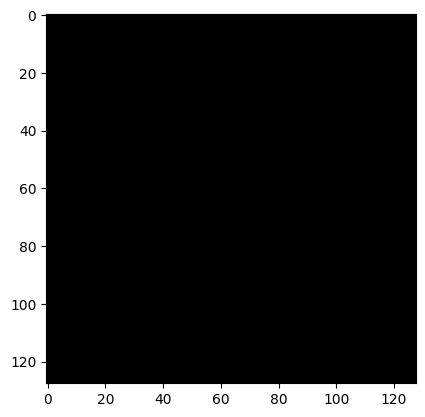

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(generation.reshape((128, 128, 3)))

In [ ]:
prediction

tensor([[0.3552]], device='cuda:0')

## **10. Training**
In this step we prepare everything needed for training the GAN model. This includes the loss function, setting up the adam optimizers, creating fixed noise for consistent image generation, and defining labels for real and fake images.

In [ ]:
import torch.optim as optim
import torchvision.utils as vutils

In [ ]:
criterion = nn.BCELoss()

fixed_noise = torch.randn(64, 100, 1, 1, device=device)

true_label = 1.0
false_label = 0.0

discriminator_optimizer = optim.Adam(discriminator.parameters(), lr = 0.0002, betas = (0.5, 0.999))
generator_optimizer = optim.Adam(generator.parameters(), lr = 0.0002, betas = (0.5, 0.999))


**11. Training the DCGAN model**

This section runs the main training loop for the GAN. The generator and discriminator are trained together. During training we also save generated images and model checkpoints so we can track the model’s progress.

In [ ]:
img_list = []
generator_losses = []
discriminator_losses = []
iters = 0

print("Training starting")

num_epochs = 100
for epoch in range(num_epochs):
  for i, data in enumerate(dataloader, 0):
    #train with real batch
    discriminator.zero_grad()

    true_gpu = data.float().to(device)

    # noise that helps stabilize GAN training (helps prevents discriminator overfitting)
    true_gpu = true_gpu + 0.05 * torch.randn_like(true_gpu)
    true_gpu = torch.clamp(true_gpu, -1, 1)

    batch_size = true_gpu.size(0)
    label = torch.full((batch_size,), true_label, dtype = torch.float, device = device)
    output = discriminator(true_gpu).view(-1)
    discriminatorErrorTrue = criterion(output, label)

    discriminatorErrorTrue.backward()
    discriminatorX = output.mean().item()
    #train with all fake batch
    noise = torch.randn(batch_size, 100, 1, 1, device = device)
    fake = generator(noise)
    fake = fake + 0.05 * torch.randn_like(fake)
    fake = torch.clamp(fake, -1, 1)
    label.fill_(false_label)
    output = discriminator(fake.detach()).view(-1)

    discriminatorErrorFake = criterion(output, label)
    discriminatorErrorFake.backward()
    discriminatorF = output.mean().item()

    discriminatorError = discriminatorErrorTrue + discriminatorErrorFake
    discriminator_optimizer.step()

    #update discriminator
    generator.zero_grad()
    label.fill_(true_label)
    output = discriminator(fake).view(-1)
    generatorError = criterion(output, label)

    generatorError.backward()
    discriminatorG = output.mean().item()
    generator_optimizer.step()

    if i % 50 == 0:
      print(f"[{epoch}/{num_epochs}][{i}/{len(dataloader)}] "
            f"Loss_D: {discriminatorError.item():.4f} "
            f"Loss_G: {generatorError.item():.4f} "
            f"D(x): {discriminatorX:.4f} "
            f"D(G(z)): {discriminatorF:.4f} / {discriminatorG:.4f}")

    generator_losses.append(generatorError.item())
    discriminator_losses.append(discriminatorError.item())

    if iters % 500 == 0 or i == len(dataloader)-1:
      with torch.no_grad():
        fake = generator(fixed_noise).detach().cpu()
      os.makedirs("generated", exist_ok=True)
      vutils.save_image(fake, f"generated/epoch_{epoch:03d}.png", normalize=True, value_range=(-1, 1))

        # Save model checkpoints (generator + discriminator)
      os.makedirs("checkpoints", exist_ok=True)
      torch.save(generator.state_dict(), f"checkpoints/G_epoch_{epoch:03d}.pth")
      torch.save(discriminator.state_dict(), f"checkpoints/D_epoch_{epoch:03d}.pth")

      img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

    iters += 1


Training starting
[0/100][0/77] Loss_D: 1.4737 Loss_G: 1.0132 D(x): 0.3552 D(G(z)): 0.3551 / 0.3631
[0/100][50/77] Loss_D: 0.3917 Loss_G: 3.6312 D(x): 0.9123 D(G(z)): 0.0446 / 0.0284
[1/100][0/77] Loss_D: 0.3502 Loss_G: 7.0305 D(x): 0.8872 D(G(z)): 0.1545 / 0.0009
[1/100][50/77] Loss_D: 0.1841 Loss_G: 6.3002 D(x): 0.9659 D(G(z)): 0.0203 / 0.0028
[2/100][0/77] Loss_D: 0.0696 Loss_G: 4.1755 D(x): 0.9791 D(G(z)): 0.0203 / 0.0154
[2/100][50/77] Loss_D: 1.2293 Loss_G: 1.7227 D(x): 0.8165 D(G(z)): 0.0661 / 0.1989
[3/100][0/77] Loss_D: 0.0271 Loss_G: 4.7901 D(x): 0.9891 D(G(z)): 0.0131 / 0.0092
[3/100][50/77] Loss_D: 0.1881 Loss_G: 4.5592 D(x): 0.9431 D(G(z)): 0.0799 / 0.0200
[4/100][0/77] Loss_D: 0.1928 Loss_G: 3.9938 D(x): 0.9542 D(G(z)): 0.0398 / 0.0245
[4/100][50/77] Loss_D: 1.4995 Loss_G: 3.6978 D(x): 0.5413 D(G(z)): 0.0060 / 0.0309
[5/100][0/77] Loss_D: 0.2305 Loss_G: 3.1461 D(x): 0.8976 D(G(z)): 0.0511 / 0.0588
[5/100][50/77] Loss_D: 1.0277 Loss_G: 3.6810 D(x): 0.7851 D(G(z)): 0.4101 /

**12. Saving generated images**

Save one of the generated image grids so that we can easily view the training progress outside the notebook.

In [ ]:
plt.imsave("./" + str(epoch) + "-generation.png", img_list[-1].permute(1, 2, 0))

**13. Upscaling Setup (Real-ESRGAN Imports)**

Import the libraries needed to use Real-ESRGAN. This model will later be used to increase the resolution of the wallpapers.

In [ ]:
# Imports for upscaling

from realesrgan import RealESRGANer  # Real-ESRGAN upscaler helper
from basicsr.archs.rrdbnet_arch import RRDBNet  # The neural network shape Real-ESRGAN uses

import torch  # GPU/CPU
import os     # folders/files
import cv2    # read/write images for RealESRGANer
import numpy as np  # arrays (sometimes useful)

**14. Download Real-ESRGAN models**

Download the pretrained Real-ESRGAN models. The x4 model produces standard upscaling, while the x4plus model produces slightly better image quality.

In [ ]:
# Download the pretrained ESRGAN models (used to upscale images)

# Improved ESRGAN model (better quality)
!wget -nc https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth

# Standard ESRGAN x4 model
!wget -nc https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4.pth

import torch

**15. Fix x4 Weight**

Converts the downloaded x4 model weights into a format that is compatible with the RealESRGANer

In [ ]:
# Make x4 weights compatible with RealESRGANer (expects key "params")
w = torch.load("RealESRGAN_x4.pth", map_location="cpu")

if isinstance(w, dict) and "params" in w:
    torch.save(w, "RealESRGAN_x4_fixed.pth")
elif isinstance(w, dict) and "params_ema" in w:
    torch.save({"params": w["params_ema"]}, "RealESRGAN_x4_fixed.pth")
else:
    # raw state_dict case
    torch.save({"params": w}, "RealESRGAN_x4_fixed.pth")

print("Saved RealESRGAN_x4_fixed.pth")

**16. Create Output Folders**

Create the folders where generated images and upscaled results will be saved.

In [ ]:
# Creates folder when GAN saves images
import os
os.makedirs("generated", exist_ok=True)
print("Folder 'generated' is ready")

## **17. Upscaling Generated Images (x4)**
This function goes through the images inside the generated folder and upscales them using the Real-ESRGAN x4 model. The upscaled images are then saved in the upscaled folder.

In [ ]:
# This function enters inside the input_folder where GAN images are saved.
# Then, upscale each image using the normal Real-ESRGAN x4 model.

def upscale_generated_images(input_folder="generated", output_folder="upscaled", scale=4):

  # Check if we can use GPU or CPU
  device = "cuda" if torch.cuda.is_available() else "cpu"

  # Create the output folder if it doesn't exist
  os.makedirs(output_folder, exist_ok=True)

  # Check if the input folder exists
  if not os.path.exists(input_folder):
    print("Input folder not found:", input_folder)
    return

  # Create the Real-ESRGAN model architecture
  model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64,
                  num_block=23, num_grow_ch=32, scale=scale)

  # Load the x4 model weights (FIXED VERSION)
  upsampler = RealESRGANer(
    scale=scale,
    model_path="RealESRGAN_x4_fixed.pth",
    model=model,
    tile=0,
    tile_pad=10,
    pre_pad=0,
    half=(device == "cuda"),
    gpu_id=0 if device == "cuda" else None
  )

  # Go through each file in the input folder
  for filename in sorted(os.listdir(input_folder)):

    # Skip files that are not images
    if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
      continue

    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, "x4_" + filename)

    # Read image using OpenCV
    img = cv2.imread(input_path, cv2.IMREAD_COLOR)

    if img is None:
      print("Could not read:", input_path)
      continue

    # Upscale image
    output, _ = upsampler.enhance(img, outscale=scale)

    # Save upscaled image
    cv2.imwrite(output_path, output)

    print("Saved (x4):", output_path)

## **18. Improved Upscaling (x4plus)**
This function tries to use the improved x4plus model to upscale the images. If the x4plus model is not available, the code automatically go back to the x4 model

In [ ]:
# This function goes to the input_folder where GAN images are saved.
# It tries to use the improved x4plus ESRGAN.
# If that is not available, it uses the normal x4 instead.

def esrgan_upscale_plus(input_folder="generated", output_folder="upscale_esrgan_plus", scale=4):

  device = "cuda" if torch.cuda.is_available() else "cpu"
  print("Device:", device)

  os.makedirs(output_folder, exist_ok=True)

  if not os.path.exists(input_folder):
    print("Input folder not found:", input_folder)
    return

  files = os.listdir(input_folder)
  print("Found", len(files), "files in", input_folder)

  model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64,
                  num_block=23, num_grow_ch=32, scale=scale)

  # Pick which weights file to use
  weights_path = "RealESRGAN_x4plus.pth"
  if os.path.exists(weights_path):
    print("Loaded x4plus weights.")
  else:
    print("x4plus not found, using normal x4 instead")
    weights_path = "RealESRGAN_x4.pth"   # <-- CHANGE THIS

    if not os.path.exists(weights_path):
      print("Missing fallback weights too:", weights_path)
      return

  upsampler = RealESRGANer(
      scale=scale,
      model_path=weights_path,
      model=model,
      tile=0,
      tile_pad=10,
      pre_pad=0,
      half=(device == "cuda"),
      gpu_id=0 if device == "cuda" else None
  )

  for filename in sorted(files):
    if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
      continue

    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, "x4plus_" + filename)

    img = cv2.imread(input_path, cv2.IMREAD_COLOR)
    if img is None:
      print("Could not read:", input_path)
      continue

    output, _ = upsampler.enhance(img, outscale=scale)
    cv2.imwrite(output_path, output)
    print("Saved (x4plus):", output_path)

**19. Upscale the Best Generated Image**

Upscale a selected best epoch image so we can produce a final high-quality wallpaper without upscaling everything.

In [ ]:
def upscale_one(filename="generated/single_epoch_049.png", out_folder="final_upscaled"):
    os.makedirs(out_folder, exist_ok=True)
    input_folder = os.path.dirname(filename)
    base = os.path.basename(filename)


    model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64,
                    num_block=23, num_grow_ch=32, scale=4)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    upsampler = RealESRGANer(
        scale=4,
        model_path="RealESRGAN_x4_fixed.pth",
        model=model,
        tile=0,
        tile_pad=10,
        pre_pad=0,
        half=(device == "cuda"),
        gpu_id=0 if device == "cuda" else None
    )

    img = cv2.imread(filename, cv2.IMREAD_COLOR)
    output, _ = upsampler.enhance(img, outscale=4)
    out_path = os.path.join(out_folder, "x4_" + base)
    cv2.imwrite(out_path, output)
    print("Saved:", out_path)

upscale_one("generated/epoch_049.png")

**20. Run the Upscaling functions**

Run the upscaling functions. Outputs will be saved to:

*   final_upscaled: the selected best image

*   upscaled: images upscaled with the x4 model

*   upscale_esrgan_plus: images upscaled with the x4plus model







In [ ]:
upscale_generated_images() # Runs the normal ESRGAN upscaling (x4 model)

esrgan_upscale_plus() # Run the improved ESRGAN upscaling (x4plus model)